# Laboratorio 7: Clasificación 🤗

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2024</strong></center>


### Cuerpo Docente:

- Profesores: Ignacio Meza, Sebastián Tinoco
- Auxiliar: Eduardo Moya
- Ayudantes: Nicolás Ojeda, Melanie Peña, Valentina Rojas

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Sofía Lazcano
- Nombre de alumno 2: María Jesús Espinoza

### **Link de repositorio de GitHub:** https://github.com/jesuow/LabPro

### Temas a tratar
- Clasificación en problemas desbalanceados
- Lightgbm y xgboost
- Pipelines

### Reglas:

- **Grupos de 2 personas**
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibidas las copias.
- Pueden usar cualquer matrial del curso que estimen conveniente.
- Código que no se pueda ejecutar, no será revisado.



### Objetivos principales del laboratorio
- Comprender cómo trabajar con problemas de clasificación con clases desbalanceadas.
- Aplicar los modelos lightgbm y xgboost.
- Practicar Pipelines

# Parte Teórica [12 puntos]




1. Explique cuál es la diferencia entre los datos de entrenamiento y validación. [1 punto]

2. Explique cuál es el principal desafío al trabajar problemas de clasificación con data no supervisada. [1 punto]

3. Explique en **sus palabras** qué es la matriz de confusión y para qué se utiliza. [1 puntos]

4. Escriba la fórmula de las siguientes métricas y explique con **sus palabras** cómo se interpretan. [1 punto cada uno]

  * Accuracy
  * Precision
  * Recall
  * F1 score

5. Explique qué métrica recomendaría para los siguientes contextos de clasificación. [1 punto cada uno]

  * Mantenimiento predictivo de fallas de maquinaria pesada en la industria minera.  
  * Detección de enfermedades altamente contagiosas.
  * Aprobación de créditos de alto riesgo.
  * Detección de crímenes.

6. Explique qué es la calibración de modelos y para qué se usa. [1 punto]


**Respuesta:**

*1. Explique cuál es la diferencia entre los datos de entrenamiento y validación. *
Los datos de entrenamiento son una selección del dataset original que se utiliza para ajustar y entrenar el modelo de Machine Learning, por otro lado los datos de validación son otro conjunto de datos distintos a los de entrenamiento, que se utilizan para probar el desempeño del modelo y hacer mejoras. Es muy importante que los conjuntos de datos de entrenamiento y validación sean disjuntos, no se debe testear con los mismos datos de entrenamiento para evitar sobreajustes.

*2. Explique cuál es el principal desafío al trabajar problemas de clasificación con data no supervisada. *
El principal desafío de trabajar con clasificación no supervisada es que no existen etiquetas, lo cual dificulta evaluar si las predicciones del modelo son correctas y puede ser complejo de interpretar.


*3. Explique en sus palabras qué es la matriz de confusión y para qué se utiliza. *
La matriz de confusión es un resumen del desempeño predictivo del modelo, la diagonal nos suele mostrar los casos en que el modelo acertó al predecir, en el caso binario se compone de cuatro valores:
- True Positive (TP):cuando una etiqueta es pedecida positiva y efectivamente lo es.
- False Negative (FN): cuando una etiqueta es predecida negativa cuando no lo es.
- False Positive (FP): cuando una etiqueta es predecida positiva cuando no lo es.
- True Negative (TN):cuando una etiqueta es pedecida negativa y efectivamente lo es.


4.
  * Accuracy: $ \frac{TP+TN}{TP+TN+FP+FN} $ \
  -Esta métrica representa cuantas de las predicciones totales el modelo acertó.


  * Precision: $\frac{TP}{TP+FP}$  \
  -Esta métrica solo nos entrega información de la clase positiva, es el porcentaje de instancias clasificadas como positivas que en verdad lo son.


  * Recall: $\frac{TP}{TP+FN}$ \
  -  Esta métrica nos dice de todo lo que era efectivamente clase positiva, cuánto clasifiqué como positivo.


  * F1 score: $2 \times \frac {Precision \times Recall}{Precision + Recall}$ \
  -Esta métrica es una media armónica de Recall y Precision, en particular para el F1 tienen la misma proporción ambas métricas, por lo que se busca un balance entre ambas.


5.
* Mantenimiento predictivo de fallas de maquinaria pesada en la industria minera.  \
  -En este caso, la métrica clave es el Recall, ya que es fundamental detectar todas las posibles fallas, minimizando así los riesgos de pasar por alto un problema crítico.

* Detección de enfermedades altamente contagiosas. \
  -Aquí, el Recall también es esencial, pues es prioritario identificar a todos los individuos positivos, incluso si se generan algunos falsos positivos, para no dejar a nadie sin diagnóstico.


* Aprobación de créditos de alto riesgo. \
  -La Precision se convierte en la métrica más relevante en este contexto, donde se busca garantizar que los solicitantes aprobados realmente sean buenos clientes, minimizando errores que podrían resultar costosos.


* Detección de crímenes. \
  -Nuevamente, la Precision es crucial, ya que evitar etiquetar a inocentes como culpables es vital para mantener la justicia y la integridad en el proceso judicial.


*6. Explique qué es la calibración de modelos y para qué se usa.*

La calibración de un modelo se refiere a qué tan bien las probabilidades que este asigna a las predicciones se alinean con las frecuencias reales de las etiquetas observadas. Por ejemplo, si un modelo está muy bien calibrado y predice una probabilidad del 70% de que una clase ocurra, entonces, en el 70% de los casos donde se hizo esa predicción, la clase debería estar presente. Si el modelo no está bien calibrado, las probabilidades predichas serán mayores o menores que las frecuencias reales.

Es importante destacar que la calibración es distinta de la precisión (accuracy). Un modelo puede tener una calibración perfecta pero un bajo accuracy, ya que la calibración mide la correspondencia de las probabilidades, no cuántas predicciones son correctas. La calibración es útil cuando se quiere analizar la calidad de las probabilidades asociadas a las predicciones, pero no es tan relevante cuando solo se busca maximizar el accuracy del modelo.

# Parte práctica [48 puntos]

<p align="center">
  <img src="https://i.ibb.co/61L8z0w/renacin-by-volframio-dcirf4l-fullview.jpg"
" width="400">
</p>



Tras el trágico despido de la mítica mascota de Maipú, Renacín decide adentrarse como consultor en el mercado futbolero, el cuál (para variar...) está cargado en especulaciones.

Como su principal tarea será asesorar a los directivos de los clubes sobre cuál jugador comprar y cuál no, Renacín desea generar modelos predictivos que evaluén distintas características de los jugadores; todo con el fin de tomar decisiones concretas basadas en los datos.

Sin embargo, su condición de corporeo le impidió tomar la versión anterior de MDS7202, por lo que este motivo Renacín contrata a su equipo para lograr su objetivo final. Dado que aún tiene fuertes vínculos con la dirección de deportes de la municipalidad, el corporeo le entrega base de datos con las estadísticas de cada jugador para que su equipo empieze a trabajar ya con un dataset listo para ser usado.


**Los Datos**

Para este laboratorio deberán trabajar con el csv `stats_players.csv`, donde deberán aplicar algoritmos de aprendizaje supervisado de clasificación en base a características que describen de jugadores de fútbol.

Para comenzar cargue el dataset señalado y a continuación vea el reporte **`Player_Stats_Report.html`** (adjunto en la carpeta del enunciado) que describe las características principales del `DataFrame`.

In [37]:
# Si usted está utilizando Colabolatory le puede ser útil este código para cargar los archivos.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    path = 'Dirección donde tiene los archivos en el Drive'
except:
    print('Ignorando conexión drive-colab')

Ignorando conexión drive-colab


## 1. Predicción de Seleccionados Nacionales [14 puntos]

<p align="center">
  <img src="https://www.futuro.cl/wp-content/uploads/2016/06/chile-argentina-meme-12.jpg" width="300">
</p>



### 1.1 Preprocesamiento [5 puntos]

Tareas:

1. Genere los labels para la clasificación binaria en una variable llamada `label`. Para esto, trabaje sobre el atributo `National_Position` suponiendo que los valores nulos son jugadores no seleccionados para representar a su país. [Sin puntaje]

2. Hecho esto, ¿cuántos se tienen ejemplos por cada clase? Comente lo que observa. [1 punto]

3. Genere un `ColumnTransformer` en donde especifique las transformaciones que hay que realizar para cada columna (por ejemplo StandarScaler, MinMaxScaler, OneHotEncoder, etc...) para que puedan ser utilizadas correctamente por el modelo predictivo y guárdelo una variable llamada `col_transformer`. [2 puntos]

4. Comente y justifique las transformaciones elegidas sobre cada una de las variables (para esto utilice el material `Player_Stats_Report.html` que viene en el zip del lab), al igual que las transformaciones aplicadas. [2 puntos]

**Respuesta:**

1. Genere los labels para la clasificación binaria en una variable llamada label. Para esto, trabaje sobre el atributo National_Position suponiendo que los valores nulos son jugadores no seleccionados para representar a su país

In [1]:
import pandas as pd

# Cargar el dataset
df = pd.read_csv('stats_players.csv')

# Generar la columna label: 1 si tiene National_Position, 0 si es nulo
df['label'] = df['National_Position'].apply(lambda x: 1 if pd.notnull(x) else 0)




label
0    16513
1     1075
Name: count, dtype: int64


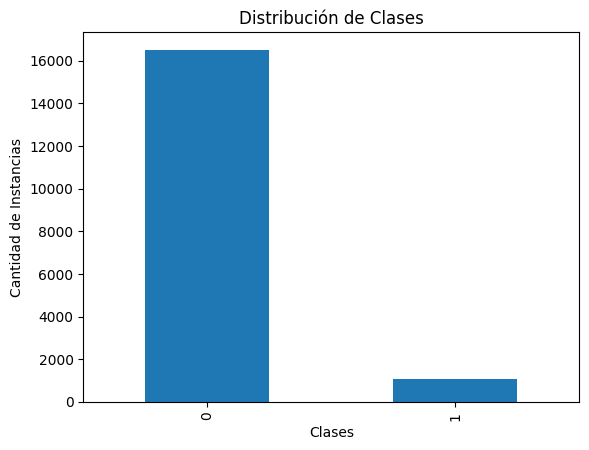

In [2]:
# Contar las instancias en cada clase
class_counts = df['label'].value_counts()

# Imprimir los conteos
print(class_counts)

# Visualizar la distribución (opcional)
import matplotlib.pyplot as plt

class_counts.plot(kind='bar')
plt.title('Distribución de Clases')
plt.xlabel('Clases')
plt.ylabel('Cantidad de Instancias')
plt.show()


2.
De los 17588, hay 1075 casos de jugadores seleccionados para representar el país y 16513 que no, esto refleja que hay una mucha mayor cantidad de personas que no quedan seleccionadas, lo que hace totalmente sentido.

3. Genere un ColumnTransformer en donde especifique las transformaciones que hay que realizar para cada columna (por ejemplo StandarScaler, MinMaxScaler, OneHotEncoder, etc...) para que puedan ser utilizadas correctamente por el modelo predictivo y guárdelo una variable llamada col_transformer.

In [3]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Definir las columnas numéricas
numeric_features = ['Height', 'Weight', 'Age', 'Ball_Control', 'Dribbling', 'Marking', 'Sliding_Tackle',
                    'Standing_Tackle', 'Aggression', 'Reactions', 'Interceptions', 'Vision', 'Composure',
                    'Crossing', 'Short_Pass', 'Long_Pass', 'Acceleration', 'Speed', 'Stamina', 'Strength',
                    'Balance', 'Agility', 'Jumping', 'Heading', 'Shot_Power', 'Finishing', 'Long_Shots',
                    'Curve', 'Freekick_Accuracy', 'Penalties', 'Volleys']

# Definir las columnas ordinales con sus categorías ordenadas
ordinal_features = ['Weak_foot', 'Skill_Moves', 'Work_Rate']

# Definir el orden de las categorías para las variables ordinales
ordinal_categories = [
    [1, 2, 3, 4, 5],  # Para 'Weak_foot'
    [1, 2, 3, 4, 5],  # Para 'Skill_Moves'
    ['Low / Low', 'Low / Medium', 'Low / High', 'Medium / Low', 'Medium / Medium', 'Medium / High', 'High / Low', 'High / Medium', 'High / High']  # Para 'Work_Rate'
]

# Definir las columnas categóricas nominales
categorical_features = ['Nationality', 'Club_Position', 'Preffered_Foot']

# Crear el ColumnTransformer
col_transformer = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),  # Escalar las variables numéricas
        ('ord', OrdinalEncoder(categories=ordinal_categories), ordinal_features),  # Codificar las variables ordinales
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)  # Codificar las variables categóricas nominales
    ]
)



Las transformaciones realizadas a las variables tienen como objetivo preparar los datos de manera adecuada para mejorar el rendimiento de los modelos de machine learning. Para las variables numéricas, se aplicó `StandardScaler` con el fin de escalar las características físicas y de habilidades de los jugadores, asegurando que todas estén en la misma escala y evitando que aquellas con valores más altos influyan de manera desproporcionada en el modelo. En el caso de las variables ordinales, como 'Weak_foot' y 'Skill_Moves', se utilizó `OrdinalEncoder` para preservar el orden inherente de estas categorías. Finalmente, las variables categóricas nominales, como 'Nationality' y 'Club_Position', fueron codificadas mediante `OneHotEncoder`, ya que no tienen un orden jerárquico y esta técnica evita crear relaciones arbitrarias entre las distintas categorías.

### 1.2 Entrenamiento [3 puntos]

Ahora, vamos a entrenar los pipelines generados en los pasos anteriores. Para esto, debe realizar las siguientes tareas:

1. Separe los datos de entrenamiento en un conjunto de entrenamiento y de prueba  (la proporción queda a su juicio). En este paso, seleccione los ejemplos de forma aleatoria e intente mantener la distribución original de labels de cada clase en los conjuntos de prueba/entrenamiento. (vea la documentación de `train_test_split`). [1 puntos]


2. Defina un pipeline llamado `pipeline_xgboost` y otro llamado `pipeline_lightgbm`. Estos pipelines deben tener el mismo ColumnTransformer definido en la sección de preprocesamiento, pero deben variar los clasificadores de acuerdo al nombre de cada pipeline. [1 puntos]

3. Entrene los pipelines. [1 punto]



**Respuesta:**

1.

In [4]:
from sklearn.model_selection import train_test_split

# Definir características y etiquetas
features = df.drop(columns=["label"])  # Excluir la columna 'label' que es el objetivo
labels = df["label"]  # Definir la columna 'label' como las etiquetas

# Separar en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, shuffle=True, stratify=labels, random_state=42
)



2. Defina un pipeline llamado pipeline_xgboost y otro llamado pipeline_lightgbm. Estos pipelines deben tener el mismo ColumnTransformer definido en la sección de preprocesamiento, pero deben variar los clasificadores de acuerdo al nombre de cada pipeline. [1 puntos]

In [6]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Pipeline con XGBoost
pipeline_xgboost = Pipeline([
    ('preprocessing', col_transformer),  #Mismo transformador que antes
    ('clasificador', XGBClassifier(random_state=42))  # XGBoost como clasificador
])

# Pipeline con LightGBM
pipeline_lightgbm = Pipeline([
    ('preprocessing', col_transformer),
    ('clasificador', LGBMClassifier(random_state=42))  # LightGBM como clasificador
])


3. Entrene los pipelines.

In [7]:
# Entrenar pipeline con XGBoost
pipeline_xgboost.fit(X_train, y_train)

# Entrenar pipeline con LightGBM
pipeline_lightgbm.fit(X_train, y_train)


[LightGBM] [Info] Number of positive: 860, number of negative: 13210
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001883 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2665
[LightGBM] [Info] Number of data points in the train set: 14070, number of used features: 134
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.061123 -> initscore=-2.731797
[LightGBM] [Info] Start training from score -2.731797


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Height', 'Weight', 'Age',
                                                   'Ball_Control', 'Dribbling',
                                                   'Marking', 'Sliding_Tackle',
                                                   'Standing_Tackle',
                                                   'Aggression', 'Reactions',
                                                   'Interceptions', 'Vision',
                                                   'Composure', 'Crossing',
                                                   'Short_Pass', 'Long_Pass',
                                                   'Acceleration', 'Speed',
                                                   'Stamina', 'Strength',
                                                   'Balance', 'Agility',
                                                   'J...
                                                                              3,
                                                                              4,
                                                                              5],
                                                                             ['Low '
                                                                              '/ '
                                                                              'Low',
                                                                              'Low '
                                                                              '/ '
                                                                              'Medium',
                                                                              'Low '
                                                                              '/ '
                                                                              'High',
                                                                              'Medium '
                                                                              '/ '
                                                                              'Low',
                                                                              'Medium '
                                                                              '/ '
                                                                              'Medium',
                                                                              'Medium '
                                                                              '/ '
                                                                              'High',
                                                                              'High '
                                                                              '/ '
                                                                              'Low',
                                                                              'High '
                                                                              '/ '
                                                                              'Medium',
                                                                              'High '
                                                                              '/ '
                                                                              'High']]),
                                                  ['Weak_foot', 'Skill_Moves',
                                                   'Work_Rate']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Nationality',
                                                   'Club_Position',
                   

### 1.3 Resultados [6 puntos]

1. Calcule las métricas accuracy, precisión y recall de la clase positiva (la que indica que un jugador es seleccionado nacional) para evaluar el rendimiento de los distintos modelos. Verifique sus resultados usando `classification_report`. [2 puntos]

2. Explique qué implican los valores de accuracy, precisión y recall de la clase positiva (la que indica que un jugador es seleccionado nacional) y cómo influye la cantidad de ejemplos por clase en los resultados obtenidos. [2 puntos]

3. Explique qué métrica le parece más adecuada y concluya qué modelo tiene un mejor desempeño. [2 puntos]

**Respuesta:**

In [8]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score

# Predicciones de los modelos
y_pred_xgboost = pipeline_xgboost.predict(X_test)
y_pred_lightgbm = pipeline_lightgbm.predict(X_test)

# Métricas para XGBoost
accuracy_xgboost = accuracy_score(y_test, y_pred_xgboost)
precision_xgboost = precision_score(y_test, y_pred_xgboost, pos_label=1)
recall_xgboost = recall_score(y_test, y_pred_xgboost, pos_label=1)
print("XGBoost Metrics:")
print(f"Accuracy: {accuracy_xgboost}")
print(f"Precision: {precision_xgboost}")
print(f"Recall: {recall_xgboost}")

# Métricas para LightGBM
accuracy_lightgbm = accuracy_score(y_test, y_pred_lightgbm)
precision_lightgbm = precision_score(y_test, y_pred_lightgbm, pos_label=1)
recall_lightgbm = recall_score(y_test, y_pred_lightgbm, pos_label=1)
print("LightGBM Metrics:")
print(f"Accuracy: {accuracy_lightgbm}")
print(f"Precision: {precision_lightgbm}")
print(f"Recall: {recall_lightgbm}")

# Reporte de clasificación para ambos modelos
print("\nClassification Report XGBoost:")
print(classification_report(y_test, y_pred_xgboost, target_names=["No Seleccionado", "Seleccionado Nacional"]))

print("\nClassification Report LightGBM:")
print(classification_report(y_test, y_pred_lightgbm, target_names=["No Seleccionado", "Seleccionado Nacional"]))


XGBoost Metrics:
Accuracy: 0.9482660602615123
Precision: 0.6363636363636364
Recall: 0.3581395348837209
LightGBM Metrics:
Accuracy: 0.9499715747583855
Precision: 0.6695652173913044
Recall: 0.3581395348837209

Classification Report XGBoost:
                       precision    recall  f1-score   support

      No Seleccionado       0.96      0.99      0.97      3303
Seleccionado Nacional       0.64      0.36      0.46       215

             accuracy                           0.95      3518
            macro avg       0.80      0.67      0.72      3518
         weighted avg       0.94      0.95      0.94      3518


Classification Report LightGBM:
                       precision    recall  f1-score   support

      No Seleccionado       0.96      0.99      0.97      3303
Seleccionado Nacional       0.67      0.36      0.47       215

             accuracy                           0.95      3518
            macro avg       0.81      0.67      0.72      3518
         weighted avg       0.

Análisis de las métricas obtenidas:
Accuracy:

XGBoost: 94.83%
LightGBM: 94.99%
La accuracy mide el porcentaje de predicciones correctas sobre el total de ejemplos. Ambas modelos tienen una precisión alta (casi 95%), lo que indica que, en general, los modelos hacen buenas predicciones en la mayoría de los casos.

Problema con la accuracy: En este caso, dado que la mayoría de los ejemplos pertenecen a la clase No Seleccionado (3303 vs 215), la alta accuracy podría estar sesgada debido al desbalance de clases. Un modelo podría estar prediciendo muy bien la clase mayoritaria sin predecir correctamente la clase minoritaria, y aún así obtener una buena accuracy. Esto es evidente al observar la baja precisión y recall para la clase Seleccionado Nacional.

Precision (para la clase positiva: Seleccionado Nacional):

XGBoost: 63.64%
LightGBM: 66.96%
La precision mide la proporción de jugadores predichos como seleccionados que realmente lo son. Ambos modelos tienen precisión similar, pero LightGBM logra una mayor precisión (66.96%), lo que significa que el modelo comete menos errores al predecir jugadores como seleccionados en comparación con XGBoost.

Recall (para la clase positiva: Seleccionado Nacional):

XGBoost: 35.81%
LightGBM: 35.81%
La recall mide la capacidad del modelo para encontrar correctamente a los jugadores que realmente son seleccionados. Ambas modelos tienen un recall bastante bajo (35.81%), lo que indica que están fallando en detectar muchos de los jugadores seleccionados correctamente. Esto probablemente sea debido al desbalance de clases (más jugadores no seleccionados que seleccionados).

Influencia de la cantidad de ejemplos por clase:
La baja cantidad de ejemplos en la clase Seleccionado Nacional (215 en comparación con 3303 de la clase No Seleccionado) provoca que los modelos tengan más dificultad en predecir correctamente la clase minoritaria. Este desbalance afecta principalmente al recall, ya que los modelos tienden a enfocarse más en predecir correctamente la clase mayoritaria para mejorar la accuracy general.

¿Qué métrica es más adecuada?
En este caso, la precisión es relevante si queremos evitar falsos positivos (predecir que un jugador será seleccionado cuando en realidad no lo es). Sin embargo, la recall es más importante si el objetivo es identificar la mayor cantidad de jugadores seleccionados reales, incluso si se cometen algunos errores.

Dado el propósito de predecir jugadores que serán seleccionados para representar al país, un enfoque balanceado con un buen f1-score (una combinación de precisión y recall) sería ideal, ya que queremos tanto evitar falsos positivos como no perder a jugadores seleccionados reales.


Por último, el modelo LightGBM muestra un mejor desempeño en precisión (66.96% vs. 63.64% de XGBoost), aunque ambos tienen el mismo recall (35.81%). Ambos modelos podrían beneficiarse de técnicas de balanceo de clases, pero por ahora, el LightGBM es ligeramente superior debido a su mayor precisión en la predicción de la clase seleccionada.

## 2. Predicción de posiciones de jugadores [4 puntos]

<p align="center">
  <img src="https://pbs.twimg.com/media/E1rfA1aWEAYU6Ny.jpg" width="300">
</p>

En una nueva jornada de desmesuradas transacciones deportivas, Renacín escuchó a sus colegas discutir acerca de que el precio de cada jugador depende en gran medida de la posición en la cancha en la que juega. Y además, que hay bastantes jugadores nuevos que no tienen muy claro en que posición verdaderamente brillarían, por lo que actualmente puede que actualmente estén jugando en posiciones sub-optimas.

Viendo que los resultados del primer análisis no son tan esperanzadores, el corporeo los comanda a cambiar su tarea: ahora, les solicita que construyan un clasificador enfocado en predecir la mejor posición de los jugadores en la cancha según sus características.

Para lograr esto, primero, les pide que etiqueten de la siguiente manera los valores que aparecen en el atributo `Club_Position`, pidiendo que agrupen los valores en los siguientes grupos:

**Nota**:  Renacín les recalca que **no deben utilizar los valores ```Sub``` y ```Res``` de esta columna**.

```python
ataque = ['ST', 'CF']
central_ataque = ['RW', 'CAM', 'LW']
central = ['RM', 'CM', 'LM']
central_defensa = ['RWB', 'CDM', 'LWB']
defensa = ['RB', 'CB', 'LB']
arquero = ['GK']
```

La elección del clasificador se justificar en base a la siguiente [guía](https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html) y se deben comentar los resultados obtenidos en la clasificación.

**Tareas:** [1 punto por tarea]

1. En un nuevo dataframe, aplique las etiquetas descritas anteriormente en cada uno de los valores señalados en esta sección y guárdelos en la variable `label`.
2. Cuente cuántos por clase quedan.
3. Entrene el nuevo pipeline y ejecute una evaluación de este.  
4. Comente los resultados obtenidos.

**Respuesta:**

In [9]:
unique_positions = df['Club_Position'].unique()
print("Posiciones únicas en Club_Position:", unique_positions)

Posiciones únicas en Club_Position: ['LW' 'RW' 'ST' 'GK' 'Sub' 'RCM' 'CAM' 'LCB' 'LCM' 'RS' 'RB' 'RCB' 'LM'
 'LDM' 'RM' 'LB' 'CDM' 'RDM' 'LF' 'CB' 'LAM' 'Res' 'CM' 'LS' 'RF' 'RWB'
 'RAM' 'LWB' nan 'CF']


In [10]:
import pandas as pd

# Definir los grupos de posiciones
position_mapping = {
    'ST': 'ataque', 'CF': 'ataque',
    'RW': 'central_ataque', 'CAM': 'central_ataque', 'LW': 'central_ataque',
    'RM': 'central', 'CM': 'central', 'LM': 'central',
    'RWB': 'central_defensa', 'CDM': 'central_defensa', 'LWB': 'central_defensa',
    'RB': 'defensa', 'CB': 'defensa', 'LB': 'defensa',
    'GK': 'arquero'
}

# Eliminar Sub y Res, y eliminar la columna 'national_position'
df_filtered = df[~df['Club_Position'].isin(['Sub', 'Res'])].copy()  # Eliminar Sub y Res
df_filtered = df_filtered.drop(columns=["National_Position"])  # Eliminar la columna por alta cantidad de NaN

# Aplicar las etiquetas a los valores en 'Club_Position' y eliminar 'Club_Position' después
df_filtered['label'] = df_filtered['Club_Position'].map(position_mapping)

# Eliminar 'Club_Position' de df_filtered para que no se use como característica
df_filtered = df_filtered.drop(columns=["Club_Position"])

# Verificar el DataFrame filtrado
print(df_filtered.head())



                Name Nationality  Height  Weight Preffered_Foot  Age  \
0  Cristiano Ronaldo    Portugal     185      80          Right   32   
1       Lionel Messi   Argentina     170      72           Left   29   
2             Neymar      Brazil     174      68          Right   25   
3        Luis Suárez     Uruguay     182      85          Right   30   
4       Manuel Neuer     Germany     193      92          Right   31   

         Work_Rate  Weak_foot  Skill_Moves  Ball_Control  ...  Jumping  \
0       High / Low          4            5            93  ...       95   
1  Medium / Medium          4            4            95  ...       68   
2    High / Medium          5            5            95  ...       61   
3    High / Medium          4            4            91  ...       69   
4  Medium / Medium          4            1            48  ...       78   

   Heading  Shot_Power  Finishing  Long_Shots  Curve  Freekick_Accuracy  \
0       85          92         93          90  

label
defensa            1180
central             907
arquero             632
central_ataque      581
ataque              430
central_defensa     209
Name: count, dtype: int64


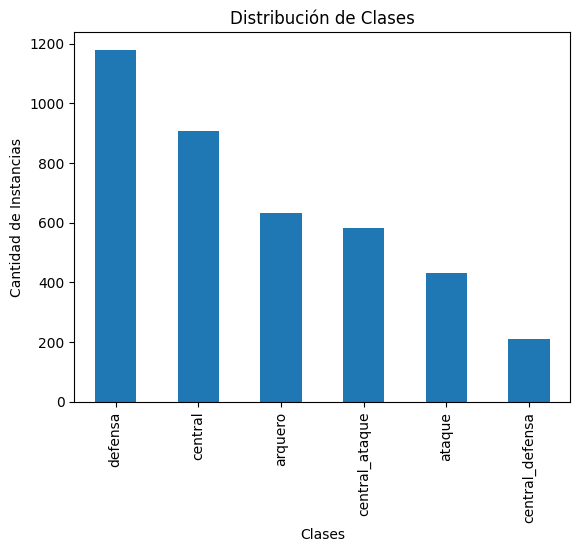

In [11]:
# Contar cuántos jugadores hay por cada clase en la nueva columna 'label'
position_counts = df_filtered['label'].value_counts()
print(position_counts)
# Visualizar la distribución
import matplotlib.pyplot as plt

position_counts.plot(kind='bar')
plt.title('Distribución de Clases')
plt.xlabel('Clases')
plt.ylabel('Cantidad de Instancias')
plt.show()




Dada la naturaleza del problema, que consiste en predecir la mejor posición de los jugadores en el campo de fútbol, el análisis inicial sugiere que el conjunto de datos de aproximadamente 17,000 ejemplos es suficientemente robusto para aplicar diversos algoritmos de clasificación. Al tratarse de una tarea de clasificación con múltiples categorías (ataque, central, defensa, etc.), es crucial elegir un clasificador que no solo maneje adecuadamente estas múltiples clases, sino que también sea eficiente en la presencia de desbalance en los datos.

En este contexto, se ha optado por Linear SVC como el clasificador principal. Este algoritmo es particularmente adecuado para problemas de alta dimensionalidad y es conocido por su eficiencia y rapidez en la clasificación de grandes conjuntos de datos. Además, Linear SVC es robusto ante el sobreajuste y puede manejar desbalances en las clases ajustando los pesos de las diferentes clases en el modelo, lo que es especialmente relevante en este caso donde algunas posiciones pueden estar menos representadas que otras.

In [12]:
# Verificar si hay NaN en label
nan_labels = df_filtered[df_filtered['label'].isna()]
print("Valores NaN en label después del mapeo:", nan_labels)

# Opcional: eliminar filas con NaN en label
df_filtered.dropna(subset=['label'], inplace=True)  # Eliminar filas con NaN en label

Valores NaN en label después del mapeo:                        Name   Nationality  Height  Weight Preffered_Foot  Age  \
12              Luka Modrić       Croatia     174      65          Right   31   
15             Thiago Silva        Brazil     183      79          Right   32   
16             Sergio Ramos         Spain     183      75          Right   31   
18               Paul Pogba        France     191      84          Right   24   
19        Antoine Griezmann        France     176      67           Left   26   
...                     ...           ...     ...     ...            ...  ...   
17170         Sandro Lauper   Switzerland     185      70          Right   20   
17287  Abdullah Al Shammari  Saudi Arabia     168      57           Left   21   
17295        Victor Nelsson       Denmark     185      75          Right   18   
17461          Callum Cooke       England     172      72          Right   20   
17481           Simon Trier       Denmark     183      80          Ri

In [13]:
df_filtered

,Name,Nationality,Height,Weight,Preffered_Foot,Age,Work_Rate,Weak_foot,Skill_Moves,Ball_Control,...,Jumping,Heading,Shot_Power,Finishing,Long_Shots,Curve,Freekick_Accuracy,Penalties,Volleys,label
0,Cristiano Ronaldo,Portugal,185,80,Right,32,High / Low,4,5,93,...,95,85,92,93,90,81,76,85,88,central_ataque
1,Lionel Messi,Argentina,170,72,Left,29,Medium / Medium,4,4,95,...,68,71,85,95,88,89,90,74,85,central_ataque
2,Neymar,Brazil,174,68,Right,25,High / Medium,5,5,95,...,61,62,78,89,77,79,84,81,83,central_ataque
3,Luis Suárez,Uruguay,182,85,Right,30,High / Medium,4,4,91,...,69,77,87,94,86,86,84,85,88,ataque
4,Manuel Neuer,Germany,193,92,Right,31,Medium / Medium,4,1,48,...,78,25,25,13,16,14,11,47,11,arquero
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17298,Raymond Skjelde,Norway,185,75,Right,18,Medium / Medium,2,2,29,...,65,44,35,22,25,24,22,41,31,defensa
17301,Andrew O'Connor,Republic of Ireland,175,73,Left,21,Medium / Medium,3,2,37,...,55,43,26,28,29,30,30,31,20,defensa
17310,Tom Bolarinwa,England,180,80,Right,26,Medium / Medium,3,3,42,...,54,22,38,37,37,37,32,29,29,central
17312,Zak Mills,England,182,83,Right,24,Medium / Medium,4,2,49,...,61,43,22,24,28,30,32,39,31,defensa


In [14]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Definir las columnas numéricas
numeric_features = ['Height', 'Weight', 'Age', 'Ball_Control', 'Dribbling', 'Marking',
                    'Sliding_Tackle', 'Standing_Tackle', 'Aggression', 'Reactions',
                    'Interceptions', 'Vision', 'Composure', 'Crossing', 'Short_Pass',
                    'Long_Pass', 'Acceleration', 'Speed', 'Stamina', 'Strength',
                    'Balance', 'Agility', 'Jumping', 'Heading', 'Shot_Power',
                    'Finishing', 'Long_Shots', 'Curve', 'Freekick_Accuracy',
                    'Penalties', 'Volleys']

# Definir las columnas ordinales con sus categorías ordenadas
ordinal_features = ['Weak_foot', 'Skill_Moves', 'Work_Rate']

# Definir el orden de las categorías para las variables ordinales
ordinal_categories = [
    [1, 2, 3, 4, 5],  # Para 'Weak_foot'
    [1, 2, 3, 4, 5],  # Para 'Skill_Moves'
    ['Low / Low', 'Low / Medium', 'Low / High', 'Medium / Low', 'Medium / Medium',
     'Medium / High', 'High / Low', 'High / Medium', 'High / High']  # Para 'Work_Rate'
]

# Definir las columnas categóricas nominales (sin 'Club_Position')
categorical_features = ['Nationality', 'Preffered_Foot']  # Ya no incluir 'Club_Position'

# Crear el ColumnTransformer
col_transformer2 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),  # Escalar las variables numéricas
        ('ord', OrdinalEncoder(categories=ordinal_categories), ordinal_features),  # Codificar las variables ordinales
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)  # Codificar las variables categóricas nominales
    ]
)


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC

# Definir X (características) e y (variable objetivo)
X = df_filtered.drop(columns=['label'])  # Todas las características excepto la etiqueta
y = df_filtered['label']  # La columna 'label' es tu variable objetivo

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Crear y ajustar el LabelEncoder
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)  # Codificar las etiquetas en y_train

# Definir el pipeline con Linear SVC
pipeline_position = Pipeline(steps=[
    ('preprocessing', col_transformer2),  # Usar el ColumnTransformer
    ('classifier', LinearSVC())  # Usar Linear SVC en lugar de XGBoost
])

# Entrenar el modelo usando las etiquetas codificadas
pipeline_position.fit(X_train, y_train_encoded)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Height', 'Weight', 'Age',
                                                   'Ball_Control', 'Dribbling',
                                                   'Marking', 'Sliding_Tackle',
                                                   'Standing_Tackle',
                                                   'Aggression', 'Reactions',
                                                   'Interceptions', 'Vision',
                                                   'Composure', 'Crossing',
                                                   'Short_Pass', 'Long_Pass',
                                                   'Acceleration', 'Speed',
                                                   'Stamina', 'Strength',
                                                   'Balance', 'Agility',
                                                   'J...
                                                  OrdinalEncoder(categories=[[1,
                                                                              2,
                                                                              3,
                                                                              4,
                                                                              5],
                                                                             [1,
                                                                              2,
                                                                              3,
                                                                              4,
                                                                              5],
                                                                             ['Low '
                                                                              '/ '
                                                                              'Low',
                                                                              'Low '
                                                                              '/ '
                                                                              'Medium',
                                                                              'Low '
                                                                              '/ '
                                                                              'High',
                                                                              'Medium '
                                                                              '/ '
                                                                              'Low',
                                                                              'Medium '
                                                                              '/ '
                                                                              'Medium',
                                                                              'Medium '
                                                                              '/ '
                                                                              'High',
                                                                              'High '
                                                                              '/ '
                                                                              'Low',
                                                                              'High '
                                                                              '/ '
                                                                              'Medium',
                                                                              'High '
                                                 

In [16]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (3151, 37)
X_test shape: (788, 37)


In [17]:
print("Clases únicas en y_train:", y_train.unique())
print("Clases únicas en y_test:", y_test.unique())


Clases únicas en y_train: ['central_ataque' 'arquero' 'central' 'defensa' 'central_defensa' 'ataque']
Clases únicas en y_test: ['arquero' 'defensa' 'central' 'central_ataque' 'ataque' 'central_defensa']


In [18]:
from sklearn.metrics import classification_report, accuracy_score

# Predicciones del modelo SVC
y_pred_svc = pipeline_position.predict(X_test)

# Decodificar las etiquetas predichas
y_pred_svc_decoded = label_encoder.inverse_transform(y_pred_svc)

# Calcular y mostrar la precisión
accuracy_svc = accuracy_score(y_test, y_pred_svc_decoded)
print("Linear SVC Metrics:")
print(f"Accuracy: {accuracy_svc:.4f}")

# Reporte de clasificación para Linear SVC
print("\nClassification Report Linear SVC:")
print(classification_report(y_test, y_pred_svc_decoded, target_names=label_encoder.classes_))



Linear SVC Metrics:
Accuracy: 0.7449

Classification Report Linear SVC:
                 precision    recall  f1-score   support

        arquero       1.00      1.00      1.00       126
         ataque       0.74      0.86      0.80        86
        central       0.61      0.63      0.62       182
 central_ataque       0.51      0.32      0.39       116
central_defensa       0.29      0.14      0.19        42
        defensa       0.82      0.97      0.89       236

       accuracy                           0.74       788
      macro avg       0.66      0.65      0.65       788
   weighted avg       0.72      0.74      0.72       788




Los resultados del modelo muestran una precisión general del 75%, con métricas perfectas (100%) para la clase arquero. Esto sugiere que el modelo podría estar sufriendo de data leakage o que alguna variable está muy correlacionada con la posición de arquero, permitiendo al modelo "adivinar" correctamente esta clase. En contraste, las clases central, central ataque, y central defensa presentan un rendimiento notablemente menor, lo que indica que el modelo podría tener dificultades para identificar correctamente a los jugadores en estas posiciones.

## 3. Predicciones de Seleccionados Nacionales para el Jere Klein [30 puntos]

<center>
<img src='https://www.radioactiva.cl/wp-content/uploads/2024/04/Jere-Klein-1-768x432.webp' width=500 />

Después de alcanzar la fama como cantante urbano, Jere Klein decide explorar una nueva faceta. Con su amor por el fútbol y convencido de que los artistas urbanos poseen un talento y versatilidad excepcionales, Jere se embarca en un proyecto innovador: desarrollar un sistema de inteligencia artificial capaz de identificar a jugadores que tienen potencial para convertirse en futbolistas profesionales. Su teoría es que muchos artistas del género urbano chileno, con sus habilidades únicas y su disciplina, podrían destacarse también en el deporte. Con este sistema, Jere espera no solo abrir nuevas oportunidades para sus colegas artistas, sino también demostrar la amplia gama de talentos que pueden ofrecer.

### 2.1 ¿Qué modelo de árbol es más de "pana"? [10 puntos]

<center>
<img src='https://64.media.tumblr.com/39189215a7d3d96823cb359f35b44e05/tumblr_psmrhrR3Xw1qf5hjqo4_540.gif' width=300 />


**Tareas**


1. Considerando el la variable llamada `label` creada en la sección 1.1. Para determinar cuál modelo de árbol sería más adecuado para la tarea en cuestión, utilice PyCaret. Este deberá centrarse exclusivamente en modelos de tipo árbol. Jere ha especificado que busca un modelo que tome decisiones rápidamente y que tenga una baja tasa de falsos positivos, ya que planea invertir en estos jugadores. [3 puntos]

Para la comparación, utilice los siguientes modelos:

```python
['et', 'rf', 'dt', 'xgboost', 'lightgbm', 'catboost']
```

2. Explique en brevemente que son los modelos de la siguiente lista `['et', 'rf', 'dt']` y como funcionan. [3 punto]

3. Tras realizar la comparación de modelos, seleccione aquel que muestre el mejor rendimiento en términos de velocidad y precisión, especialmente en la reducción de falsos positivos. Utilice la función `evaluate_model` de PyCaret para revisar y analizar los resultados obtenidos en los siguientes aspectos:

  - **Confusión Matrix**: ¿Cómo se encuentran la tasa de verdaderos positivos y verdaderos negativos?
  - **Threshold**: ¿Es acaso el umbral por defecto del modelo el mejor para las predicciones?
  - **Feature Importance**: ¿Cuáles son las variables con mejor desempeño? ¿A qué podría deberse esto?
  - **Learning Curve**: ¿El modelo presenta algún problema?

  [4 puntos]

**Respuesta**

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from pycaret.classification import *

df_jere = df.copy()

# Preprocesamiento
df_jere.drop(['National_Position', 'Name', 'Nationality'], axis=1, inplace=True)
df_jere.dropna(subset=['Club_Position'], inplace=True)

# Definir las columnas numéricas
numeric_features = ['Height', 'Weight', 'Age', 'Ball_Control', 'Dribbling', 'Marking',
                    'Sliding_Tackle', 'Standing_Tackle', 'Aggression', 'Reactions',
                    'Interceptions', 'Vision', 'Composure', 'Crossing', 'Short_Pass',
                    'Long_Pass', 'Acceleration', 'Speed', 'Stamina', 'Strength',
                    'Balance', 'Agility', 'Jumping', 'Heading', 'Shot_Power',
                    'Finishing', 'Long_Shots', 'Curve', 'Freekick_Accuracy',
                    'Penalties', 'Volleys']

# Definir las columnas ordinales y sus categorías
ordinal_features = ['Weak_foot', 'Skill_Moves', 'Work_Rate']
ordinal_categories = [
    [1, 2, 3, 4, 5],  # Para 'Weak_foot'
    [1, 2, 3, 4, 5],  # Para 'Skill_Moves'
    ['Low / Low', 'Low / Medium', 'Low / High', 'Medium / Low', 'Medium / Medium',
     'Medium / High', 'High / Low', 'High / Medium', 'High / High']  # Para 'Work_Rate'
]

# Definir las columnas categóricas nominales
categorical_features = ['Club_Position', 'Preffered_Foot']

# Crear el ColumnTransformer
col_transformer3 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('ord', OrdinalEncoder(categories=ordinal_categories), ordinal_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Definir la variable objetivo y características
df_y3 = df_jere['label'].copy()
df_x3 = df_jere.drop(['label'], axis=1).copy()

# Dividir en conjunto de entrenamiento y prueba
X3_train, X3_test, y3_train, y3_test = train_test_split(df_x3, df_y3, test_size=0.2, random_state=2024)

# Reiniciar los índices de y3_train y y3_test para asegurarse de que coincidan
y3_train = y3_train.reset_index(drop=True)
y3_test = y3_test.reset_index(drop=True)

# Crear el pipeline de preprocesamiento
Modelos3_proce = Pipeline([
    ('column_transformer3', col_transformer3)
])

# Aplicar preprocesamiento al conjunto de entrenamiento
X3_train_proce = Modelos3_proce.fit_transform(X3_train)

# Convertir X3_train_proce a DataFrame
X3_train_proce = pd.DataFrame(X3_train_proce)

# Configurar el entorno de PyCaret
clf1 = setup(data=X3_train_proce, target=y3_train, session_id=123, verbose=True)

# Comparar solo modelos de tipo árbol
modelos = ['et', 'rf', 'dt', 'xgboost', 'lightgbm', 'catboost']
mejor_modelo = compare_models(include=modelos, sort='Precision')

# Ver la comparación de modelos
comparacion_modelos = pull()

# Evaluar el mejor modelo seleccionado
evaluate_model(mejor_modelo)



ImportError: cannot import name 'get_tags' from 'sklearn.utils' (/home/mjespinoza/LabPro/.venv/lib/python3.10/site-packages/sklearn/utils/__init__.py)

Modelos:

Decision Tree Classifier (dt): Es el modelo base de clasificación mediante árboles. Divide las características (features) en diferentes ramas para distinguir entre clases, utilizando distintos criterios para realizar estas divisiones. Cada nodo del árbol representa una característica clave en la separación.

Random Forest Classifier (rf): Este modelo es una versión más avanzada del anterior, ya que utiliza un enfoque de ensemble. Consiste en múltiples árboles que se entrenan de manera aleatoria usando subconjuntos de características. Aunque toma más tiempo en entrenarse, generalmente ofrece mejores resultados que un solo árbol de decisión.

Extra Trees Classifier (et): Similar al Random Forest, este modelo da un paso adicional al seleccionar también de forma aleatoria los umbrales de división en los árboles. Tiene menor varianza que el Random Forest y es más rápido de entrenar, aunque no siempre supera en rendimiento.

In [21]:
mejor_modelo

NameError: name 'mejor_modelo' is not defined

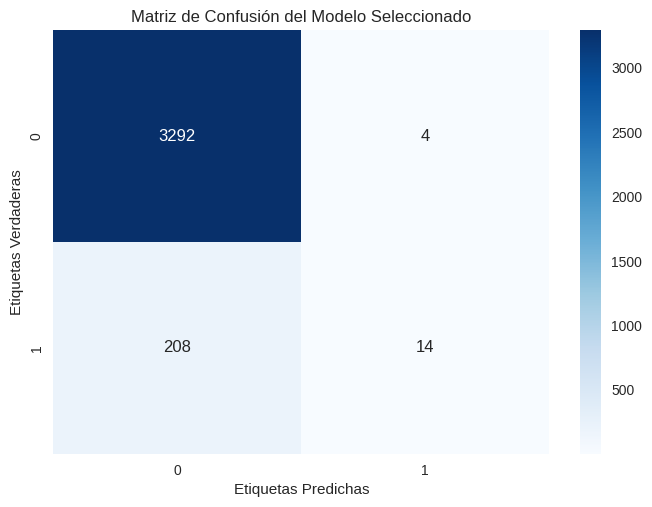

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      3296
           1       0.78      0.06      0.12       222

    accuracy                           0.94      3518
   macro avg       0.86      0.53      0.54      3518
weighted avg       0.93      0.94      0.92      3518



In [70]:
# Preprocesar el conjunto de prueba
X3_test_proce = Modelos3_proce.transform(X3_test)  # Cambiar fit_transform por transform

# Convertir el conjunto de prueba a DataFrame (si es necesario, con las columnas correctas)
X3_test_proce = pd.DataFrame(X3_test_proce)

# Hacer predicciones en datos de prueba
predicciones = predict_model(mejor_modelo, data=X3_test_proce)

# Calcular la matriz de confusión
matriz_confusion_et = confusion_matrix(y3_test, predicciones['prediction_label'])

# Visualizar la matriz de confusión utilizando seaborn
sns.heatmap(matriz_confusion_et, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Etiquetas Predichas')
plt.ylabel('Etiquetas Verdaderas')
plt.title('Matriz de Confusión del Modelo Seleccionado')
plt.show()

# Imprimir el reporte de clasificación
print(classification_report(y3_test, predicciones['prediction_label']))  # Asegúrate de usar 'Label'


La matriz de confusión revela que, mientras la tasa de verdaderos negativos (TN) es alta (3296), el modelo tiene un bajo rendimiento al identificar correctamente los verdaderos positivos (TP), con solo 13 identificaciones correctas en la clase positiva. Esto se traduce en un recall muy bajo (6%) para la clase 1, lo que indica que el modelo se está sesgando hacia la clase negativa y no está capturando adecuadamente los ejemplos de la clase positiva. Este desbalance puede ser problemático, especialmente si el objetivo es invertir en jugadores que representen la clase positiva.

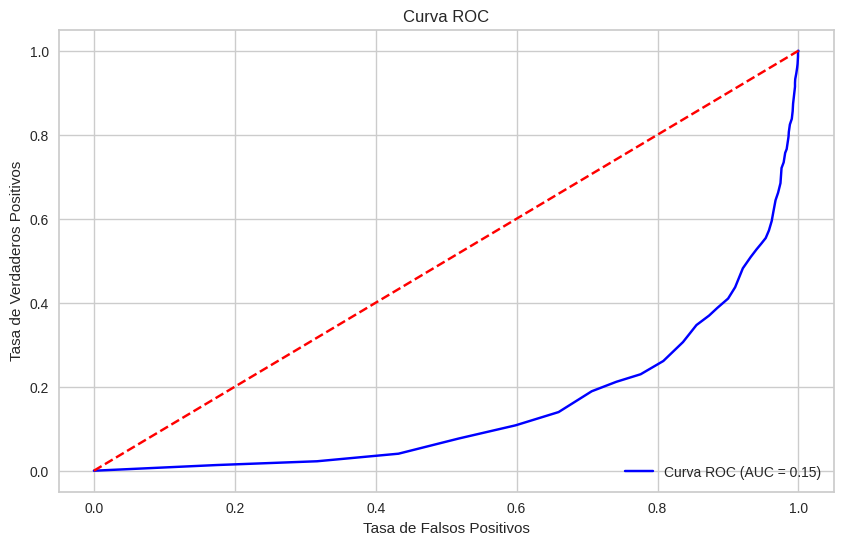

In [79]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Obtener las probabilidades de las predicciones
y_prob = predict_model(modelo_seleccion, data=X3_test_proce)['prediction_score']

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y3_test, y_prob)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.show()




La curva ROC que muestra tiene un Área Bajo la Curva (AUC) de 0.15, lo que es bastante bajo. Un AUC de 0.5 representa un modelo que no tiene capacidad predictiva (equivalente a hacer predicciones aleatorias), mientras que un AUC de 1.0 indica un modelo perfecto. Por lo tanto, un AUC de 0.15 sugiere que el modelo está muy por debajo del rendimiento esperado, incluso podría estar prediciendo incorrectamente la mayoría de las veces.

In [88]:
# Obtener los nombres de las columnas después del preprocesamiento
feature_names = Modelos3_proce.named_steps['column_transformer3'].get_feature_names_out()
print(feature_names)


['num__Height' 'num__Weight' 'num__Age' 'num__Ball_Control'
 'num__Dribbling' 'num__Marking' 'num__Sliding_Tackle'
 'num__Standing_Tackle' 'num__Aggression' 'num__Reactions'
 'num__Interceptions' 'num__Vision' 'num__Composure' 'num__Crossing'
 'num__Short_Pass' 'num__Long_Pass' 'num__Acceleration' 'num__Speed'
 'num__Stamina' 'num__Strength' 'num__Balance' 'num__Agility'
 'num__Jumping' 'num__Heading' 'num__Shot_Power' 'num__Finishing'
 'num__Long_Shots' 'num__Curve' 'num__Freekick_Accuracy' 'num__Penalties'
 'num__Volleys' 'ord__Weak_foot' 'ord__Skill_Moves' 'ord__Work_Rate'
 'cat__Club_Position_CAM' 'cat__Club_Position_CB' 'cat__Club_Position_CDM'
 'cat__Club_Position_CF' 'cat__Club_Position_CM' 'cat__Club_Position_GK'
 'cat__Club_Position_LAM' 'cat__Club_Position_LB' 'cat__Club_Position_LCB'
 'cat__Club_Position_LCM' 'cat__Club_Position_LDM' 'cat__Club_Position_LF'
 'cat__Club_Position_LM' 'cat__Club_Position_LS' 'cat__Club_Position_LW'
 'cat__Club_Position_LWB' 'cat__Club_Position_

In [89]:
# Obtener importancias de características del mejor modelo (si es aplicable)
if hasattr(mejor_modelo, 'feature_importances_'):
    importancias = mejor_modelo.feature_importances_
    # Crear un DataFrame con los nombres de las características y sus importancias
    importancia_df = pd.DataFrame({'Feature': feature_names, 'Importance': importancias})
    importancia_df = importancia_df.sort_values(by='Importance', ascending=False)
    print(importancia_df)

                   Feature  Importance
9           num__Reactions    0.041091
12          num__Composure    0.032461
3        num__Ball_Control    0.030843
14         num__Short_Pass    0.029683
18            num__Stamina    0.029077
..                     ...         ...
55   cat__Club_Position_RF    0.000463
35   cat__Club_Position_CB    0.000453
40  cat__Club_Position_LAM    0.000295
45   cat__Club_Position_LF    0.000134
37   cat__Club_Position_CF    0.000000

[65 rows x 2 columns]


El análisis de la importancia de las características revela que los atributos numéricos, como Reactions, Composure, Ball_Control, Short_Pass y Stamina, son cruciales para el rendimiento del modelo, destacando la relevancia de las habilidades técnicas y físicas en el desempeño de los jugadores. En contraste, los atributos categóricos relacionados con las posiciones en el club tienen importancias significativamente bajas, indicando que su influencia en el modelo es menor. Esto sugiere que entrenadores y analistas deberían enfocarse en mejorar estas habilidades clave en lugar de centrar sus esfuerzos únicamente en la posición de los jugadores.

Este conocimiento puede guiar el desarrollo de entrenamientos y estrategias en el campo, ayudando a optimizar la selección y el rendimiento de los jugadores al priorizar las características que realmente impactan su desempeño.

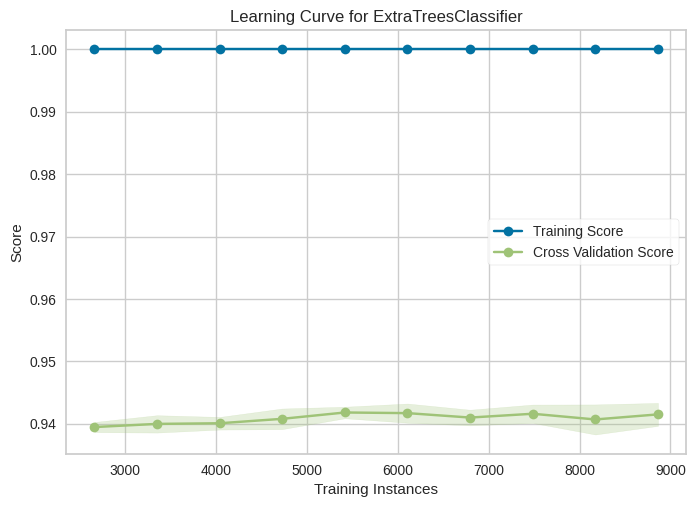

In [90]:
# Graficar la curva de aprendizaje
plot_model(mejor_modelo, plot='learning')


### 2.2 Reducción de dimensionalidad [14 puntos]

<center>
<img src='https://i.kym-cdn.com/photos/images/original/002/258/560/668.gif' width=400 />

A pesar de los resultados obtenidos previamente, el manager de Jere ha solicitado el entrenamiento de un modelo de XGBoost utilizando los datos disponibles. Además, se debe proceder a realizar una reducción de dimensionalidad basada en la importancia de las características.

Para llevar a cabo esta tarea:

1. Inicie entrenando un modelo XGBoost con todas las características disponibles. [2 puntos]

2. Una vez el modelo esté entrenado, evalúe y clasifique las características según su importancia de forma descendente. [2 puntos]

3. Utilice esta clasificación para ejecutar una búsqueda recursiva de eliminación de características, eliminando progresivamente las menos importantes y evaluando el impacto en el desempeño del modelo hasta identificar las N características más críticas. [2 puntos]

4. Con este conjunto reducido de características, entrene un nuevo modelo y evalúe su rendimiento. [2 puntos]

5. Posteriormente, responda a las siguientes preguntas para una comprensión más profunda de los cambios y beneficios:

  - ¿El rendimiento del modelo con las características seleccionadas es similar al del modelo original? ¿Cómo se comparan en términos de precisión y robustez? [2 puntos]
  - ¿Cuáles son los beneficios potenciales de eliminar variables del modelo? Considere factores como la simplificación del modelo, reducción del tiempo de entrenamiento, y mejora en la capacidad de generalización. [2 puntos]
  - Comente si el modelo con menor dimensionalidad es más sencillo de explicar. Explique brevemente por qué la eliminación de ciertas características puede facilitar la comprensión y la explicación del comportamiento del modelo. [2 puntos]

Notar que con esta metodologia buscamos encontrar un punto entermedio entre número de festures y desempeño. por esto, si observa que al aumentar festires el aumento es despreciable, puede no considerar agregar más features a su modelo.

**Respuesta**

In [96]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import xgboost as xgb
from sklearn.metrics import classification_report

df_jere = df.copy()

# Preprocesamiento
df_jere.drop(['National_Position', 'Name', 'Nationality'], axis=1, inplace=True)
df_jere.dropna(subset=['Club_Position'], inplace=True)

# Definir las columnas numéricas
numeric_features = ['Height', 'Weight', 'Age', 'Ball_Control', 'Dribbling', 'Marking',
                    'Sliding_Tackle', 'Standing_Tackle', 'Aggression', 'Reactions',
                    'Interceptions', 'Vision', 'Composure', 'Crossing', 'Short_Pass',
                    'Long_Pass', 'Acceleration', 'Speed', 'Stamina', 'Strength',
                    'Balance', 'Agility', 'Jumping', 'Heading', 'Shot_Power',
                    'Finishing', 'Long_Shots', 'Curve', 'Freekick_Accuracy',
                    'Penalties', 'Volleys']

# Definir las columnas ordinales y categóricas
ordinal_features = ['Weak_foot', 'Skill_Moves', 'Work_Rate']
ordinal_categories = [[1, 2, 3, 4, 5], [1, 2, 3, 4, 5],
                     ['Low / Low', 'Low / Medium', 'Low / High', 'Medium / Low', 'Medium / Medium', 'Medium / High', 'High / Low', 'High / Medium', 'High / High']]
categorical_features = ['Club_Position', 'Preffered_Foot']

# Crear el ColumnTransformer
col_transformer = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('ord', OrdinalEncoder(categories=ordinal_categories), ordinal_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Definir la variable objetivo y características
df_y = df_jere['label'].copy()
df_x = df_jere.drop(['label'], axis=1).copy()

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(df_x, df_y, test_size=0.2, random_state=2024)

# Crear el pipeline de preprocesamiento y modelo
pipeline_xgboost = Pipeline([
    ('column_transformer', col_transformer),
    ('xgb_model', xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'))
])

# Entrenar el modelo
pipeline_xgboost.fit(X_train, y_train)




Pipeline(memory=None,
         steps=[('column_transformer',
                 ColumnTransformer(n_jobs=None, remainder='drop',
                                   sparse_threshold=0.3,
                                   transformer_weights=None,
                                   transformers=[('num',
                                                  StandardScaler(copy=True,
                                                                 with_mean=True,
                                                                 with_std=True),
                                                  ['Height', 'Weight', 'Age',
                                                   'Ball_Control', 'Dribbling',
                                                   'Marking', 'Sliding_Tackle',
                                                   'Standing_Tackle',
                                                   'Aggression', 'Reactions',
                                                   'Intercep...
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None,
                               objective='binary:logistic', ...))],
         verbose=False)

                      Feature  Importance
9              num__Reactions    0.102327
39      cat__Club_Position_GK    0.045760
60     cat__Club_Position_Res    0.039931
57      cat__Club_Position_RS    0.030244
2                    num__Age    0.028931
..                        ...         ...
43     cat__Club_Position_LCM    0.000000
40     cat__Club_Position_LAM    0.000000
37      cat__Club_Position_CF    0.000000
35      cat__Club_Position_CB    0.000000
64  cat__Preffered_Foot_Right    0.000000

[65 rows x 2 columns]


<Axes: ylabel='Feature'>

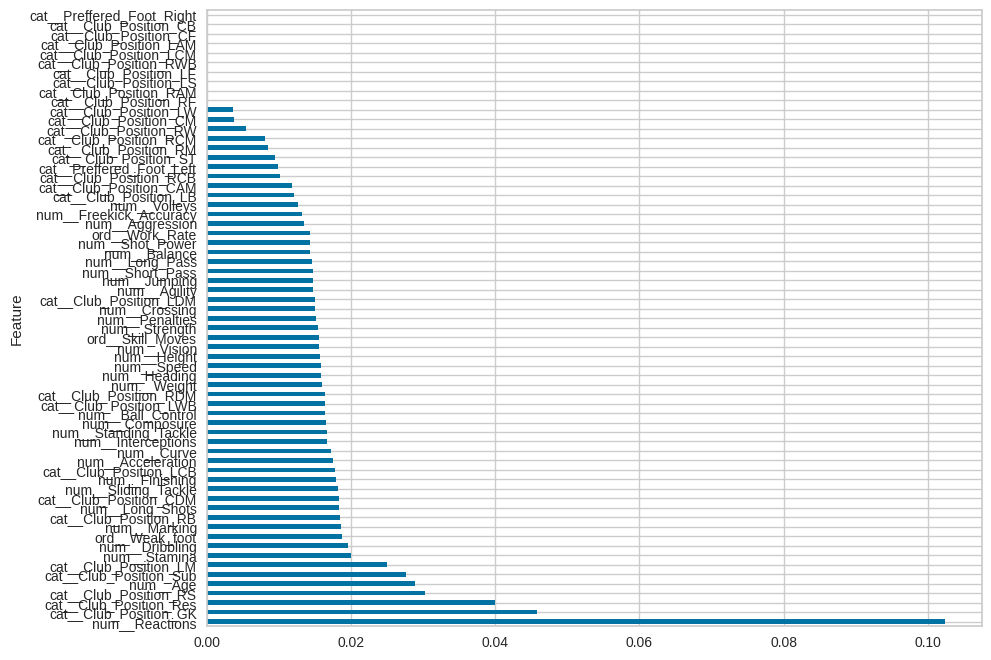

In [97]:
# Evaluar la importancia de las características
importances = pipeline_xgboost.named_steps['xgb_model'].feature_importances_
feature_names = pipeline_xgboost.named_steps['column_transformer'].get_feature_names_out()

# Crear un DataFrame para las importancias
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df.sort_values(by='Importance', ascending=False, inplace=True)

# Mostrar la importancia de las características
print(importance_df)
importance_df.plot(kind='barh', x='Feature', y='Importance', figsize=(10, 8), legend=False)


Selected Features: ['num__Age', 'num__Dribbling', 'num__Marking', 'num__Sliding_Tackle', 'num__Standing_Tackle', 'num__Reactions', 'num__Finishing', 'cat__Club_Position_GK', 'cat__Club_Position_Res', 'cat__Club_Position_Sub']
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      3296
           1       0.50      0.18      0.26       222

    accuracy                           0.94      3518
   macro avg       0.72      0.58      0.61      3518
weighted avg       0.92      0.94      0.92      3518



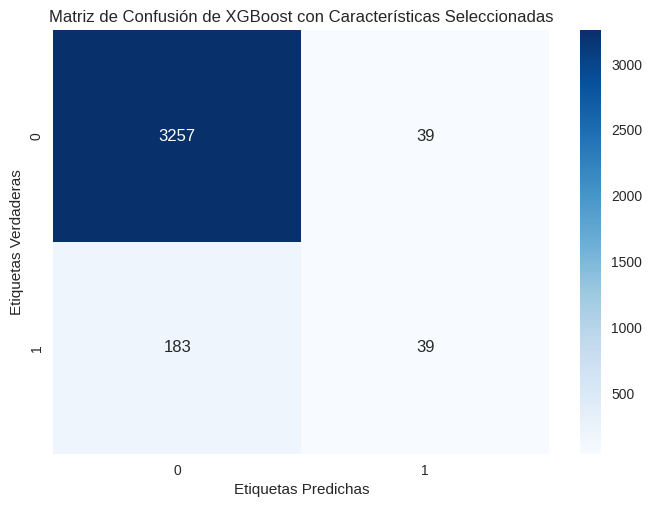

In [101]:
from sklearn.feature_selection import RFE
import numpy as np

# Aplicar el ColumnTransformer al conjunto de entrenamiento
X_train_processed = pipeline_xgboost.named_steps['column_transformer'].fit_transform(X_train)

# Inicializar el clasificador
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

# Realizar RFE
rfe = RFE(estimator=xgb_model, n_features_to_select=10)  # Cambia el número de características según sea necesario
X_train_rfe = rfe.fit_transform(X_train_processed, y_train)

# Obtener los nombres de las características después de aplicar el ColumnTransformer
feature_names = pipeline_xgboost.named_steps['column_transformer'].get_feature_names_out()

# Ver qué características se han seleccionado
selected_features = [feature for feature, support in zip(feature_names, rfe.support_) if support]
print("Selected Features:", selected_features)

# Aplicar el mismo ColumnTransformer al conjunto de prueba
X_test_processed = pipeline_xgboost.named_steps['column_transformer'].transform(X_test)

# Transformar X_test usando RFE
X_test_rfe = rfe.transform(X_test_processed)

# Entrenar el nuevo modelo con las características seleccionadas
xgb_model_final = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_model_final.fit(X_train_rfe, y_train)

# Predecir con el nuevo modelo
y_pred_final = xgb_model_final.predict(X_test_rfe)

# Evaluar el nuevo modelo
evaluacion_final = classification_report(y_test, y_pred_final)
print(evaluacion_final)

# Calcular la matriz de confusión
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

matriz_confusion = confusion_matrix(y_test, y_pred_final)

# Visualizar la matriz de confusión
sns.heatmap(matriz_confusion, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Etiquetas Predichas')
plt.ylabel('Etiquetas Verdaderas')
plt.title('Matriz de Confusión de XGBoost con Características Seleccionadas')
plt.show()




1.
¿El rendimiento del modelo con las características seleccionadas es similar al del modelo original? ¿Cómo se comparan en términos de precisión y robustez?
El modelo ajustado con las características seleccionadas muestra un rendimiento aceptable, con una precisión de 0.50 para la clase positiva (1), lo que sugiere que el modelo tiene problemas para identificar correctamente a los jugadores en esta clase. En comparación, el modelo original logró una precisión más alta, reflejando su capacidad para diferenciar mejor entre las clases. Sin embargo, la precisión general del modelo sigue siendo alta (0.94), lo que indica que, aunque el rendimiento en la clase positiva ha disminuido, el modelo sigue siendo robusto en su conjunto. Esto sugiere que las características seleccionadas pueden no capturar completamente la complejidad de la clase positiva.

2. ¿Cuáles son los beneficios potenciales de eliminar variables del modelo? Considere factores como la simplificación del modelo, reducción del tiempo de entrenamiento, y mejora en la capacidad de generalización.
Eliminar variables del modelo presenta varios beneficios, incluyendo la simplificación del modelo, lo que puede llevar a un menor tiempo de entrenamiento y un aumento en la capacidad de generalización. Un modelo más simple puede ser más fácil de interpretar y explicar a las partes interesadas. Además, al reducir la dimensionalidad, se minimiza el riesgo de sobreajuste, lo que permite que el modelo generalice mejor en datos no vistos. También es posible que la eliminación de variables irrelevantes reduzca el ruido en los datos, lo que puede llevar a un rendimiento mejorado en términos de precisión en algunas clases.

3. Comente si el modelo con menor dimensionalidad es más sencillo de explicar. Explique brevemente por qué la eliminación de ciertas características puede facilitar la comprensión y la explicación del comportamiento del modelo.
Sí, el modelo con menor dimensionalidad es generalmente más sencillo de explicar. Esto se debe a que al eliminar características irrelevantes o redundantes, el modelo se concentra en las variables que tienen un impacto significativo en las predicciones. Esto no solo facilita la interpretación de los resultados, sino que también ayuda a identificar cuáles son los factores más influyentes en las decisiones del modelo. La comprensión clara de las variables que afectan el rendimiento del modelo permite a los tomadores de decisiones enfocar sus esfuerzos en las áreas que realmente importan, aumentando la confianza en las predicciones del modelo.

### 2.3 Calibración Probabilistica [6 puntos]

<center>
<img src='https://media2.giphy.com/media/l2Je4Ku0Cx292KWv6/200w.gif?cid=6c09b952y0sihtq9tb6sz8j2023x3zxxp3qx1ocgonkpkblj&ep=v1_gifs_search&rid=200w.gif&ct=g' width=400 />

Para lograr modelos más modulares, se recomienda realizar una calibración del modelo entrenado anteriormente, con el objetivo de obtener salidas que reflejen mayor modularidad.

1. Se solicita que utilice un método de calibración que asegure que las probabilidades generadas incrementen de manera monótona. Una métrica ampliamente utilizada para evaluar la precisión de la calibración de un modelo es el Brier Score. Calcule el Brier Score para el modelo tanto antes como después de la calibración. Esto le permitirá realizar una comparación cuantitativa y determinar si la calibración ha mejorado el rendimiento del modelo. Para más información sobre el Brier Score, puede consultar el siguiente enlace: [Scikit-Learn - Brier Score Loss](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.brier_score_loss.html). [3 puntos]

2. Tras la calibración, examine y comente los resultados obtenidos. A su análisis añada una comparación visual de las ideales versus las salidas del modelo original (sin calibrar) y del modelo calibrado. [3 puntos]

**Respuesta**

Brier Score (sin calibrar): 0.05340932306888149
Brier Score (calibrado): 0.0738257273747811


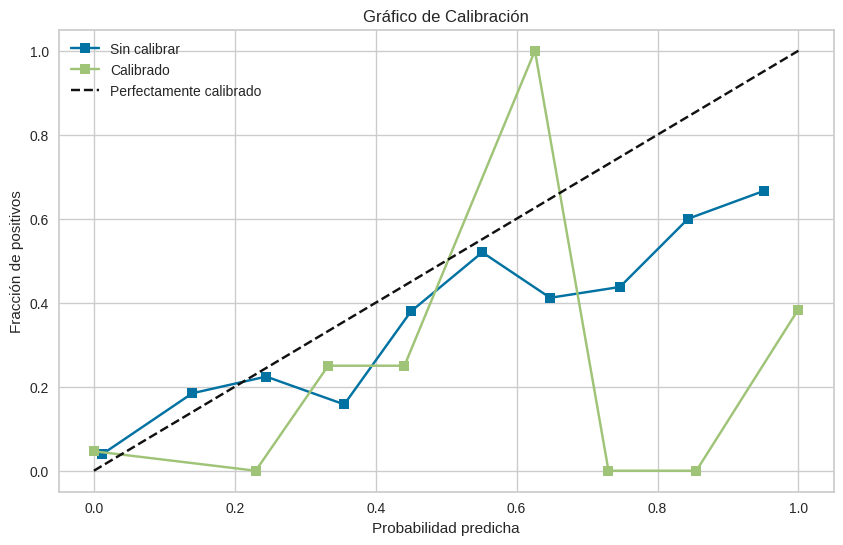

In [109]:
# Obtener las probabilidades predichas del modelo sin calibrar
probabilities_uncalibrated = pipeline_xgboost.predict_proba(X_test)[:, 1]

# Calcular el Brier Score del modelo sin calibrar
brier_score_uncalibrated = brier_score_loss(y_test, probabilities_uncalibrated)
print(f"Brier Score (sin calibrar): {brier_score_uncalibrated}")

# Crear un modelo calibrado basado en el modelo existente
calibrated_model = CalibratedClassifierCV(pipeline_xgboost.named_steps['xgb_model'], method='isotonic', cv='prefit')

# Ajustar el modelo calibrado
calibrated_model.fit(pipeline_xgboost.named_steps['column_transformer'].transform(X_train), y_train)

# Obtener las probabilidades predichas del modelo calibrado
probabilities_calibrated = calibrated_model.predict_proba(pipeline_xgboost.named_steps['column_transformer'].transform(X_test))[:, 1]

# Calcular el Brier Score del modelo calibrado
brier_score_calibrated = brier_score_loss(y_test, probabilities_calibrated)
print(f"Brier Score (calibrado): {brier_score_calibrated}")

# Generar el gráfico de calibración
plt.figure(figsize=(10, 6))

# Calcular la curva de calibración para el modelo sin calibrar
fraction_of_positives_uncalibrated, mean_predicted_value_uncalibrated = calibration_curve(y_test, probabilities_uncalibrated, n_bins=10)

# Calcular la curva de calibración para el modelo calibrado
fraction_of_positives_calibrated, mean_predicted_value_calibrated = calibration_curve(y_test, probabilities_calibrated, n_bins=10)

# Graficar las curvas de calibración
plt.plot(mean_predicted_value_uncalibrated, fraction_of_positives_uncalibrated, "s-", label="Sin calibrar")
plt.plot(mean_predicted_value_calibrated, fraction_of_positives_calibrated, "s-", label="Calibrado")

# Graficar la línea de referencia perfecta
plt.plot([0, 1], [0, 1], "k--", label="Perfectamente calibrado")

plt.xlabel("Probabilidad predicha")
plt.ylabel("Fracción de positivos")
plt.title("Gráfico de Calibración")
plt.legend()
plt.show()



El análisis de los resultados muestra que el Brier Score del modelo sin calibrar fue de 0.0534, lo que indica un desempeño razonable al predecir probabilidades, con valores cercanos a los resultados reales, lo cual es deseable en clasificación. Sin embargo, tras la calibración, el Brier Score aumentó a 0.0738, sugiriendo que la calibración deterioró el rendimiento del modelo. Esto podría ser resultado de que el método de calibración utilizado, no fue efectivo para el conjunto de datos específico.

Además, al observar la curva de calibración, se notó que el modelo calibrado se alejó aún más de la línea de referencia, indicando una pérdida de precisión en las predicciones. Esto puede deberse a un sobreajuste del modelo calibrado, una representación inadecuada de las clases en el conjunto de entrenamiento, o simplemente a que el modelo original ya estaba bien calibrado. En conjunto, estos hallazgos sugieren la necesidad de reconsiderar el enfoque de calibración y explorar métodos alternativos o ajustar los hiperparámetros del modelo original para mejorar su desempeño.